seeing what impact increase on neurons has. validate on x alone

In [291]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import ast


In [292]:
plt.rcParams["font.family"]   = "DejaVu Sans"  # or "Times New Roman", etc.
plt.rcParams["font.size"]     = 8           # base font size
plt.rcParams["axes.titlesize"] = 10        # all titles
plt.rcParams["axes.labelsize"] = 8         # all x/y labels


In [293]:
dtype=torch.float32
device = 'cpu'

In [294]:
txt = open("N=10000-dt=2.5e-05-force=sin(2pi200t).txt").read().split('\t')
         # list of strings
f = np.array(txt, dtype=float)      # 30000 floats
t = torch.tensor(f[:10000], dtype =dtype)
u= torch.tensor(f[10000:20000],dtype =dtype)
x = torch.tensor(f[20000:30000],dtype =dtype)
v = torch.tensor(f[30000:],dtype =dtype)
print(len(f))
print(x)


40000
tensor([0.0000e+00, 0.0000e+00, 1.9632e-11,  ..., 5.7095e-08, 3.3124e-08,
        9.1173e-09])


In [ ]:
#normalisation 


def zscore_normalize(x: torch.Tensor):
    """
    x: 1D tensor (N,) or (N,1)
    returns: x_norm, mean, std  with x_norm = (x-mean)/std
    """
    if x.dim() == 2 and x.size(1) == 1:
        x = x.view(-1)

    mean = x.mean()
    std = x.std(unbiased=False)  # population std; use unbiased=True if you prefer

    # avoid divide by zero
    std_safe = std.clone()
    if std_safe == 0:
        std_safe = torch.tensor(1.0, dtype=x.dtype, device=x.device)

    x_norm = (x - mean) / std_safe
    return x_norm, mean, std_safe


def zscore_denormalize(x_norm: torch.Tensor, mean: torch.Tensor, std: torch.Tensor):
    """
    Invert z-score: x = x_norm * std + mean
    """
 
    return x_norm * std + mean


In [296]:
x_train_norm, x_mean, x_std = zscore_normalize(x)
u_train_norm, u_mean, u_std = zscore_normalize(u)
v_train_norm, v_mean, v_std = zscore_normalize(v)




u_v = torch.stack([x[1:], v[1:]] , dim = 0)

Z = torch.stack([x[:-1], v[:-1], u[:-1]], dim=1)  # shape (T-1, 3)
print(Z[0,:].size())
# Targets Y_t = [x_t, v_t]
Y = torch.stack([x[1:], v[1:]], dim=1) 

# Closed-form LS: Y ≈ Z W, W shape (3,2)
Z_T = Z.T                                          # (3, T-1)
W_star = torch.linalg.lstsq(Z_T @ Z, Z_T @ Y).solution  # (3,2)
# Or, more simply (but less stable): W_star = torch.linalg.inv(Z_T @ Z) @ (Z_T @ Y)


torch.Size([3])


In [297]:
k = (2*np.pi*100)**2
m = 1
zeta, f_n = 0.015, 100.0      # 100 Hz
wn = 2 * np.pi * f_n
c = 2 * zeta * m * wn

# dt = t[1].item()
dt = 2.5e-5
N = len(t)
print(N)
print(dt)
N_list = np.arange(N)*dt
Nl = torch.tensor(N_list, dtype=dtype, device=device)
print(f'time increment: {dt} s, total time: {N*dt} s')
I2 = torch.tensor([[1,0],[0,1]], dtype=dtype).to(device)
A2 = torch.tensor([[0,1],[-k/m,-c/m]], dtype=dtype).to(device)
B2 = torch.tensor([[0],[1/m]], dtype=dtype).to(device)


Adisc = torch.linalg.inv(I2-dt*0.5*A2)@(I2+dt*0.5*A2)
Bdisc = torch.linalg.inv(I2-dt*0.5*A2)@(dt*B2)

x0 = torch.tensor([0,0],dtype=torch.float32)
x0_n = torch.tensor([x_train_norm[0],v_train_norm[0]],dtype=torch.float32)
##tustin discretization

print(torch.linalg.eigvals(Adisc))
print(Bdisc)

10000
2.5e-05
time increment: 2.5e-05 s, total time: 0.25 s
tensor([0.9996+0.0157j, 0.9996-0.0157j])
tensor([[3.1241e-10],
        [2.4993e-05]])


In [298]:
class NARX(nn.Module):
    def __init__(self,neurons, A =None, B =None):
        super().__init__()
        self.hidden = nn.Linear(neurons+1, neurons, bias=False)
        self.out = nn.Linear(neurons,2, bias=False)
        self.neurons = neurons
  
            
    def forward(self, u, x0 = torch.tensor([0,0],dtype=torch.float32)):
        # closed loop rollout
        extra = torch.zeros(self.neurons  -2)
        x0 = torch.cat([x0, extra], dim = -1)
        out = [x0]

        for i in range(1, len(u)):
            x_prev = out[i-1]                       # previous state 
            u_prev = u[i-1].view(1)                 # previous external input
            inp = torch.cat((x_prev, u_prev), dim=0)# model input 
            xi = self.hidden(inp)                   # apply learned weights to input
            out.append(xi)
        stack = torch.stack(out, dim=0) 
        print(stack)
        output = self.out(stack )
        return   output     # C= [1,0] therefore x_1 is first entry of each state in 'out'

    def open_loop_train(self, z):
        """
        z: (T, 3) = [x_true, v_true, u]
        returns: (T, 2) predicted [x, v]
        """
        T = z.size(0)
        device = z.device
        dtype = z.dtype

        # initial full state: first 2 from data, rest zeros
        if self.neurons > 2:
            extra0 = torch.zeros(self.neurons - 2, device=device, dtype=dtype)
            state = torch.cat([z[0, 0:2], extra0], dim=-1)   # (neurons,)
        else:
            state = z[0, 0:2]

        preds = []

        for t in range(T):
            u_t = z[t, 2:3]                                  # shape (1,)

            # recurrent update: f(state_{t-1}, u_t)
            inp = torch.cat([z[t, 0:2], state[2:], u_t], dim=-1)            # (neurons+1,)
            state = self.hidden(inp)                         # (neurons,)

            # teacher forcing on first two coords
            # state = torch.cat([z[t, 0:2], state[2:]], dim=-1)

            preds.append(state)

        out = self.out(torch.stack(preds, dim=0))
        return out
       


In [299]:
# loss functions
def batch_loss(pred, target, model=None):
    
    z = nn.MSELoss()(pred, target)
    return z


In [300]:
# training
def train_model(model, optimizer, x_train, v_train, f_train, epochs=5000, exit = 1e-14, loss_fn=batch_loss):
    model.train()
     # CORRECT SHAPES: Z (N-1, 3), Y_target (N-1, 2)
    Z= torch.stack([x_train[:-1], v_train[:-1], f_train[:-1]], dim=1)  # (N-1, 3)
    Y_target = torch.stack([x_train[1:], v_train[1:]], dim=1)                     # (N-1, 2)
    for epoch in range(epochs):
        optimizer.zero_grad()
    
        pred = model.open_loop_train(Z)
        target = Y_target
  
        # print(f'shape uvnorm {uvnorm.size()}, shape pred {pred.size()}')
        loss = nn.MSELoss()(pred, target)
        loss.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
        if loss.item() < exit:
            print(f"Early stopping at epoch {epoch}, Loss: {loss.item()}")
            break

In [301]:
model = NARX(2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

tensor([[-1.2013e-02, -4.4183e-05],
        [ 3.9303e-03, -3.1148e-03],
        [ 1.1963e-02, -2.2813e-02],
        ...,
        [-1.6653e-02,  5.7043e-02],
        [-1.1247e-02,  4.1441e-02],
        [-5.8306e-03,  2.5798e-02]], grad_fn=<StackBackward0>)
noir
tensor([[ 0.0012, -0.0004],
        [ 0.0017, -0.0006],
        [ 0.0140, -0.0048],
        ...,
        [-0.0363,  0.0124],
        [-0.0264,  0.0091],
        [-0.0166,  0.0057]], grad_fn=<MmBackward0>)
std
tensor(8.1011e-07)
pred tensor([[ 1.0694e-08,  9.3943e-09],
        [ 1.1101e-08,  9.2646e-09],
        [ 2.1073e-08,  5.8465e-09],
        ...,
        [-1.9659e-08,  1.9812e-08],
        [-1.1686e-08,  1.7078e-08],
        [-3.6929e-09,  1.4337e-08]], grad_fn=<AddBackward0>)
x tensor([0.0000e+00, 0.0000e+00, 1.9632e-11,  ..., 5.7095e-08, 3.3124e-08,
        9.1173e-09])
 initial loss: 9.039140963507108e-13


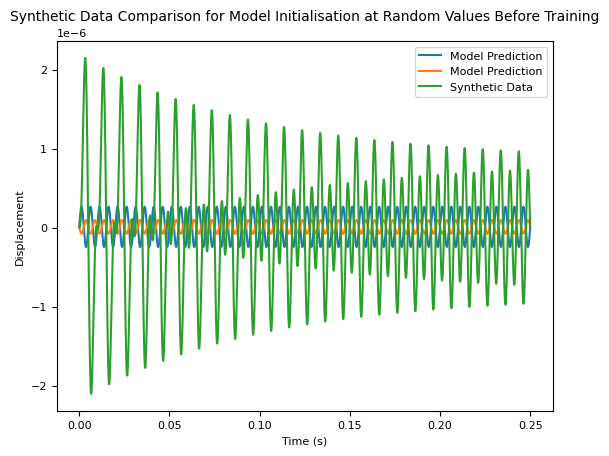

In [302]:
x0_norm = torch.tensor([x_train_norm[0],v_train_norm[0]],dtype=torch.float32)
pred = model(u_train_norm,x0_norm )
pred= zscore_denormalize(pred,x_mean, x_std)

print(f'pred {pred}')
print(f'x {x}')
print(f' initial loss: {nn.MSELoss()(pred[:,0],x)}')

plt.plot(t,pred.detach(), label = 'Model Prediction')
plt.plot(t,x, label  = 'Synthetic Data')
plt.legend()
plt.title("Synthetic Data Comparison for Model Initialisation at Random Values Before Training")
plt.xlabel("Time (s)")          # x‑axis label
plt.ylabel("Displacement")
plt.show()



In [303]:
train_model(model, optimizer, x_train_norm[:4000],v_train_norm[:4000], u_train_norm[:4000], exit = 7e-9,epochs=1000000)
# prediction_loop(model, x_train, f_train

Epoch 0, Loss: 2.1429684162139893
Epoch 100, Loss: 0.03132599592208862
Epoch 200, Loss: 4.6669327275594696e-05
Epoch 300, Loss: 2.0731123129280604e-07
Early stopping at epoch 391, Loss: 6.992808998518285e-09


tensor([[-1.2013e-02, -4.4183e-05],
        [ 1.2749e-02,  5.5521e-03],
        [-6.4604e-03, -1.2621e-02],
        ...,
        [        nan,         nan],
        [        nan,         nan],
        [        nan,         nan]], grad_fn=<StackBackward0>)
noir
tensor([[ 7.7080e-03, -3.4609e-03],
        [-1.2012e-02,  7.2043e-05],
        [ 1.2912e-02,  6.3786e-03],
        ...,
        [        nan,         nan],
        [        nan,         nan],
        [        nan,         nan]], grad_fn=<MmBackward0>)
std
tensor(8.1011e-07)


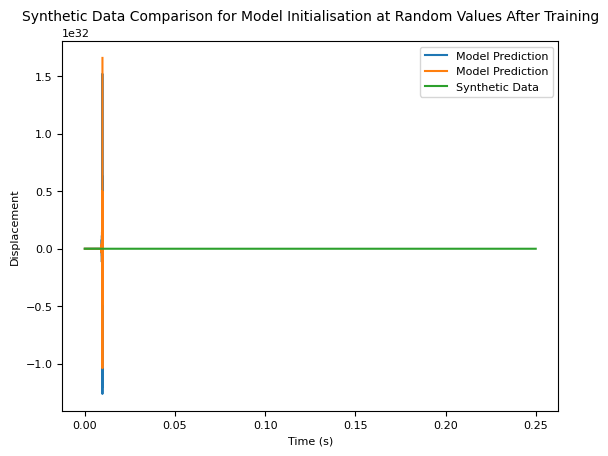

In [ ]:
predaf = model(u_train_norm, x0_norm)

predaf = zscore_denormalize(predaf, x_mean, x_std)

plt.plot(t,predaf.detach(), label = 'Model Prediction')
plt.plot(t,x, label  = 'Synthetic Data')
plt.legend()
plt.title("Synthetic Data Comparison for Model Initialisation at Random Values After Training")
plt.xlabel("Time (s)")          # x‑axis label
plt.ylabel("Displacement")
plt.show()


In [305]:
txt1 = open("N=10000-dt=2.5e-05-force=sin(2pi500t).txt").read().split('\t')
         # list of strings
f1 = np.array(txt1, dtype=float)   

t1=f1[:10000]  # 30000 floats
t1 = torch.tensor(t1, dtype =dtype)
u1 = f1[10000:20000]
u1= torch.tensor(u1,dtype =dtype)
x1=f1[20000:30000]
x1 = torch.tensor(x1,dtype =dtype)
v1=f1[30000:]
v1 = torch.tensor(v1,dtype =dtype)



In [306]:
u1_norm, u1_mean, u1_std = zscore_normalize(u1)
x1_norm , x1_mean, x1_std = zscore_normalize(x1)
v1_norm , v1_mean, v1_std = zscore_normalize(v1)
x01_norm = torch.tensor([x1_norm[0],v1_norm[0]],dtype=torch.float32)
test_pred = model(u1_norm, x01_norm)



tensor([[-0.0163, -0.0001],
        [ 0.0172,  0.0076],
        [-0.0075, -0.0183],
        ...,
        [    nan,     nan],
        [    nan,     nan],
        [    nan,     nan]], grad_fn=<StackBackward0>)


noir
tensor([[ 1.0486e-02, -4.6607e-03],
        [-1.6288e-02,  4.8652e-05],
        [ 1.7483e-02,  9.7882e-03],
        ...,
        [        nan,         nan],
        [        nan,         nan],
        [        nan,         nan]], grad_fn=<MmBackward0>)
std
tensor(8.1011e-07)


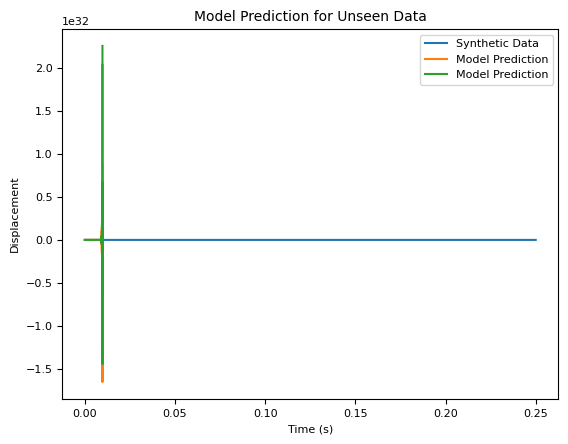

tensor(0.)
tensor([1.8227e-08, 5.9565e-09], grad_fn=<SelectBackward0>)


In [307]:
test_pred = zscore_denormalize(test_pred, x_mean,x_std)
plt.plot(t, x1, label = 'Synthetic Data')
plt.plot(t, test_pred.detach(), label = 'Model Prediction')
plt.legend()

plt.title("Model Prediction for Unseen Data")
plt.xlabel("Time (s)")          # x‑axis label
plt.ylabel("Displacement")
plt.show()

print(x1[0])
print( test_pred[0])

tensor([[-1.2013e-02, -4.4183e-05,  0.0000e+00],
        [-1.0082e-03,  4.4972e-03, -3.5829e-03],
        [-1.3995e-02,  1.3865e-02, -7.6853e-03],
        ...,
        [ 1.2771e-01, -2.0296e-01,  4.8714e-02],
        [ 1.0367e-01, -1.6741e-01,  3.8187e-02],
        [ 7.9517e-02, -1.3170e-01,  2.7622e-02]], grad_fn=<StackBackward0>)


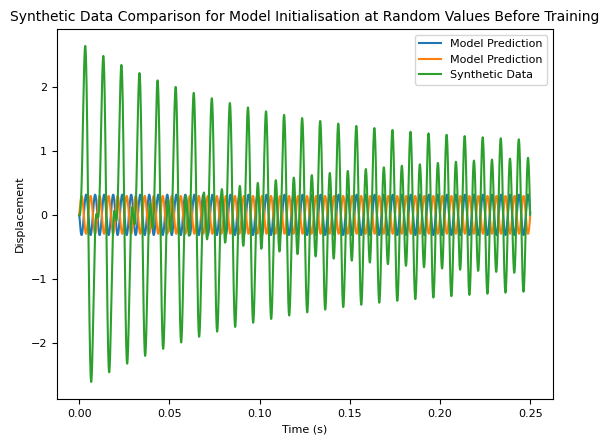

In [308]:
model3 = NARX(3)

pred3 = model3(u_train_norm, x0_norm)
plt.plot(t,pred3.detach(), label = 'Model Prediction')
plt.plot(t,x_train_norm, label  = 'Synthetic Data')
plt.legend()
plt.title("Synthetic Data Comparison for Model Initialisation at Random Values Before Training")
plt.xlabel("Time (s)")          # x‑axis label
plt.ylabel("Displacement")
plt.show()

In [309]:
optimizer3 = torch.optim.Adam(model.parameters(), lr=1e-2)
train_model(model3, optimizer3, x_train_norm[:4000],v_train_norm[:4000], u_train_norm[:4000], exit = 7e-9,epochs=1000000)

Epoch 0, Loss: 1.032449722290039
Epoch 100, Loss: 1.032449722290039
Epoch 200, Loss: 1.032449722290039


KeyboardInterrupt: 